In [18]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold

from tqdm import tqdm

Load MNI mask for cleaning betas

In [3]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

Resample MNI mask

In [8]:
temp_nii_path = 'F:\yujun\projects\AI_IAPS\GLM_singletrial\/betas\Sub3\/beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)

In [9]:
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)

Load beta series and apply mask

In [48]:
dataDir = '../GLM_singletrial/betas/'
subs = os.listdir(dataDir)
sub = subs[2]

delay_length = [0,1,1.8,2,3,3.6,4,5,5.4,6,7,7.2,8,9,10,11,12]
delay_betas = []

for d in range(len(delay_length)):
    sub_dir = os.path.join(dataDir, sub, f'delay_{delay_length[d]}')
    print(f'reading betas from {sub_dir}' )
    filenames = os.listdir(sub_dir)

    beta_idx = []
    for i in range(0 ,10): # runs
        id = [(x + 66*i) for x in range(1,61)]
        beta_idx.append(id)
    beta_id = np.array(beta_idx).reshape(1, -1)


    # Extract the IDs from the filenames
    file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
    # Filter the filenames based on the ID list
    selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]

    beta_arrays = []
    for i in range(len(selected_filenames)):
        # Load the NIfTI file
        file_path = os.path.join(sub_dir, selected_filenames[i])
        nii_data = nib.load(file_path)
        # Apply the mask to the NIfTI image
        masked_data = masking.apply_mask(nii_data, resampled_mask)
        # Get the mask's indices in the original 3D shape
        mask_indices = np.where(resampled_mask.get_fdata())
        # Create a new 3D array filled with zeros
        reshaped_data = np.zeros(nii_data.shape)
        # Fill the new 3D array with the values from the masked data
        reshaped_data[mask_indices] = masked_data
        beta_arrays.append(reshaped_data)

    delay_betas.append(beta_arrays)

reading betas from ../GLM_singletrial/betas/Sub3\delay_0
reading betas from ../GLM_singletrial/betas/Sub3\delay_1
reading betas from ../GLM_singletrial/betas/Sub3\delay_1.8
reading betas from ../GLM_singletrial/betas/Sub3\delay_2
reading betas from ../GLM_singletrial/betas/Sub3\delay_3
reading betas from ../GLM_singletrial/betas/Sub3\delay_3.6
reading betas from ../GLM_singletrial/betas/Sub3\delay_4
reading betas from ../GLM_singletrial/betas/Sub3\delay_5
reading betas from ../GLM_singletrial/betas/Sub3\delay_5.4
reading betas from ../GLM_singletrial/betas/Sub3\delay_6
reading betas from ../GLM_singletrial/betas/Sub3\delay_7
reading betas from ../GLM_singletrial/betas/Sub3\delay_7.2
reading betas from ../GLM_singletrial/betas/Sub3\delay_8
reading betas from ../GLM_singletrial/betas/Sub3\delay_9
reading betas from ../GLM_singletrial/betas/Sub3\delay_10
reading betas from ../GLM_singletrial/betas/Sub3\delay_11
reading betas from ../GLM_singletrial/betas/Sub3\delay_12


In [49]:
np.array(delay_betas[0]).shape

(600, 79, 95, 79)

In [50]:
# Compare if the two arrays are equal
if np.array_equal(np.array(delay_betas[0]), np.array(delay_betas[1])):
    print("The arrays are the same.")
else:
    print("The arrays are different.")

The arrays are different.


Load stimuli sequence

In [19]:
stim_dir = 'F:\yujun\projects\LAB_IAPS_AI\data\stimulus_v2'
stim_files = natsorted(os.listdir(stim_dir))
stimuli = []
for i, file in enumerate(stim_files):
    txt_path = os.path.join(stim_dir, file)
    data_array = np.loadtxt(txt_path, dtype=str)
    stimuli.append(data_array)
stimuli = np.array(stimuli).flatten()

Add stimuli types

In [20]:
stim_types = pd.read_csv('F:\yujun\projects\LAB_IAPS_AI\data\iaps_emotion_category_v2.csv')
stimuli_df = pd.DataFrame({'Sequence': stimuli})
# Add an 'OriginalOrder' column to the df DataFrame
stimuli_df['OriginalOrder'] = stimuli_df.index
# Merge the two DataFrames based on the StimulusID column
merged_df = stimuli_df.merge(stim_types, left_on='Sequence', right_on='img')
# Sort the merged DataFrame based on the 'OriginalOrder' column
merged_df = merged_df.sort_values(by='OriginalOrder')
stimuli = merged_df[['OriginalOrder','img','emotion_type', 'AI', 'group']].reset_index(drop=True)
stimuli

,OriginalOrder,img,emotion_type,AI,group
0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...
595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,2446.jpg,neutral,NO,neutral
598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


Load Kastner mask

In [21]:
roi_id = np.arange(1, 26)
roi_labels = ['V1v',	    
 'V1d',	   
 'V2v',   
 'V2d',	   
 'V3v',	    
 'V3d',	    
 'hV4',	  
 'VO1',	    
 'VO2',	    
 'PHC1',	    
 'PHC2',	    
 'MST',	    
 'hMT',	   
 'LO2',	    
 'LO1',	   
 'V3b',	    
 'V3a',	  
 'IPS0',	   
 'IPS1',	    
 'IPS2',	    
 'IPS3',	  
 'IPS4',	  
 'IPS5',	  
 'SPL1',	 
 'FEF'	]

roi_bin = []
roi_mask = []

for i in range(len(roi_id)):
    kastner_dir = 'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all'
    kastner_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_lh.nii.gz')
    kastner_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_rh.nii.gz')
    kastner_combine = kastner_l.get_fdata() + kastner_r.get_fdata()
    kastner_combine_nii = nib.Nifti1Image(kastner_combine, kastner_l.affine)
    # Resample Kastner mask
    kastner_resample = resample_img(kastner_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    # Create a binary mask where values > 0 are set to 1 and other values are set to 0
    kastner_resample_bin = np.where(kastner_resample.get_fdata() > 10, 1, 0)
    roi_bin.append(kastner_resample_bin)
    roi_mask.append(nib.Nifti1Image(kastner_resample_bin, temp_nii_data.affine))

kastner_dict = dict(zip(roi_labels, roi_bin))

Load AAL3 mask

In [22]:
aal3_label = [
 'ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
#  'CingulateAnt',
#  'CingulateMid',
#  'CingulatePost',
 'Cuneus',
 'Fusiform',
 'Hippocampus',
 'Insula',
 'Lingual',
 'ParaHippocampal',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'ThalPuL'
]

aal3_bins = []
aal3_masks = []

for i in range(len(aal3_label)):
    aal3_nii = nib.load(f'F:\yujun\projects\data\masks\AAL3\\new\{aal3_label[i]}.nii.gz')
    aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)
    aal3_masks.append(nib.Nifti1Image(aal3_bin, temp_nii_data.affine))
    aal3_bins.append(aal3_bin)

aal3_dict = dict(zip(aal3_label, aal3_bins))

In [32]:
kastner_dict.update(aal3_dict)
roi_dict = kastner_dict
len(roi_dict)
# roi_dict.keys()

43

SVM

In [33]:
new_roi_dict  = {list(roi_dict.keys())[0]: list(roi_dict.values())[0]}

In [106]:
len(decode_ids_run)

9

In [102]:
decode_ids = []
decode_names = []

# RUN 1,2
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 119, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 119, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 119, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 1
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 59, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 59, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 59, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 2
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(60, 119, inclusive=True) )[0])
decode_names.append('Decode pleasant vs. neutral images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(60, 119, inclusive=True))[0])
decode_names.append('Decode pleasant vs. unpleasant images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(60, 119, inclusive=True))[0])
decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 3
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(120, 179, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(120, 179, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(120, 179, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 1,2,3
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 179, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 179, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 179, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 1,2,4
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 239, inclusive=True)))
#     )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 239, inclusive=True)))
#     )[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 239, inclusive=True)))
#     )[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 1,2,4,5
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 299, inclusive=True)))
#     )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 299, inclusive=True)))
#     )[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 299, inclusive=True)))
#     )[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 3,4
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(120, 239, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(120, 239, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(120, 239, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 1,2,3,4
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 239, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 239, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 239, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

# RUN 1,2,3,4, 5
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')


#RUN 7,8
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(360, 479, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(360, 479, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(360, 479, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

#RUN 9, 10
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(480, 599, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(480, 599, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(480, 599, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')


#RUN 7,8,9,10
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(360, 599, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(360, 599, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(360, 599, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

#RUN 1,2,3,4,5,6
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 359, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 359, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 359, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

#RUN 1,2,3,4,5,6
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 359, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 359, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 359, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

#RUN 1,2,3,4,7,8,9,10
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & ~stimuli['OriginalOrder'].between(240, 359, inclusive=True) )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & ~stimuli['OriginalOrder'].between(240, 359, inclusive=True))[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & ~stimuli['OriginalOrder'].between(240, 359, inclusive=True))[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

#RUN 1,2,4,5,7,8,9,10
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 299, inclusive=True)) | (stimuli['OriginalOrder'].between(360, 599, inclusive=True)) )
#     )[0])
# decode_names.append('Decode pleasant vs. neutral images.')
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 299, inclusive=True)) | (stimuli['OriginalOrder'].between(360, 599, inclusive=True)) )
#     )[0])
# decode_names.append('Decode pleasant vs. unpleasant images.')
# decode_ids.append(np.where(
#     ((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & 
#     ((stimuli['OriginalOrder'].between(0, 119, inclusive=True)) | (stimuli['OriginalOrder'].between(180, 299, inclusive=True)) | (stimuli['OriginalOrder'].between(360, 599, inclusive=True)) )
#     )[0])
# decode_names.append('Decode unpleasant vs. neutral images.')

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\1663599119.py:21: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(60, 119, inclusive=True) )[0])
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\1663599119.py:23: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(60, 119, inclusive=True))[0])
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\1663599119.py:25: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'ne

In [103]:
# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

delay_rois = []

for d in range(len(delay_betas)):

    beta_series = np.array(delay_betas[d])
    flat_betas = beta_series.reshape((600, -1))

    rois = []

    print(f'Now decoding delay: {delay_length[d]}')

    # Iterate through the values of roi_dict
    for roi_name, roi_bin in tqdm(new_roi_dict.items()):
        flat_roi = roi_bin.ravel()
        roi_betas = flat_betas[:, flat_roi == 1]

        print(f'Now decoding {roi_name}')

        cases = []
        for i, decode_id in enumerate(decode_ids):
            data = roi_betas[decode_id, :]  # (600, number of roi voxels)
            if i < 9:
                labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)
            elif i >= 9:
                labels = stimuli['AI'][decode_id].reset_index(drop=True)

            linear_svc_scores = []
            
            # 10-fold cross-validation
            for train_index, test_index in rskf.split(data, labels):
                X_train, X_test = data[train_index], data[test_index]
                y_train, y_test = labels[train_index], labels[test_index]

                # Create SVC classifiers with different kernels
                linear_svc = SVC(kernel='linear', random_state=42)

                # Fit the model
                linear_svc.fit(X_train, y_train)

                # Evaluate the model
                linear_score = linear_svc.score(X_test, y_test)
                linear_svc_scores.append(linear_score)

            # Compute average accuracy for Linear SVC over the 10 folds
            avg_linear_score = np.mean(linear_svc_scores)

            # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
            # print("Average Linear SVC accuracy:", avg_linear_score)
            # print("------------------")
            cases.append(avg_linear_score)

        # print('=============================================')
        rois.append(cases)
    rois_arr = np.array(rois)
    delay_rois.append(rois_arr)

Now decoding delay: 0


  0%|          | 0/1 [00:00<?, ?it/s]

Now decoding V1v


100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


Now decoding delay: 1


...

100%|██████████| 1/1 [00:01<00:00,  1.27s/it]


Now decoding delay: 12


  0%|          | 0/1 [00:00<?, ?it/s]

Now decoding V1v


100%|██████████| 1/1 [00:01<00:00,  1.16s/it]


single run, e.g. 1, 2, 3, 4. ...

In [117]:
decode_ids_run = []
decode_names_run = []

for i in range(1,11):
    decode_ids = []
    decode_names = []
    decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(60*(i-1), 60*i-1, inclusive=True) )[0])
    decode_names.append('Decode pleasant vs. neutral images.')
    decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(60*(i-1), 60*i-1, inclusive=True))[0])
    decode_names.append('Decode pleasant vs. unpleasant images.')
    decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(60*(i-1), 60*i-1, inclusive=True))[0])
    decode_names.append('Decode unpleasant vs. neutral images.')

    decode_ids_run.append(decode_ids)
    decode_names.append(decode_names_run)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\1151228356.py:7: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(60*(i-1), 60*i-1, inclusive=True) )[0])
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\1151228356.py:9: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(60*(i-1), 60*i-1, inclusive=True))[0])
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\1151228356.py:11: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emoti

multiple rum, e. g. 12345

In [122]:
decode_ids_run = []
decode_names_run = []


decode_ids = []
decode_names = []
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True) )[0])
decode_names.append('Decode pleasant vs. neutral images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
decode_names.append('Decode pleasant vs. unpleasant images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
decode_names.append('Decode unpleasant vs. neutral images.')

decode_ids_run.append(decode_ids)
decode_names.append(decode_names_run)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\3091868739.py:7: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True) )[0])
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\3091868739.py:9: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18828\3091868739.py:11: FutureWarning: Boolean inputs to the `inclusive` argument are deprecated in favour of `both` or `neither`.
  decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutra

In [123]:
# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

delay_rois_run = []

for run in range(len(decode_ids_run)):
    decode_ids = decode_ids_run[run]

    delay_rois = []

    for delay in range(len(delay_betas)):

        beta_series = np.array(delay_betas[delay])
        flat_betas = beta_series.reshape((600, -1))

        rois = []

        print(f'Now decoding delay: {delay_length[d]}')

        # Iterate through the values of roi_dict
        for roi_name, roi_bin in tqdm(new_roi_dict.items()):
            flat_roi = roi_bin.ravel()
            roi_betas = flat_betas[:, flat_roi == 1]

            print(f'Now decoding {roi_name}')

            cases = []
            for i, decode_id in enumerate(decode_ids):
                data = roi_betas[decode_id, :]  # (600, number of roi voxels)
                if i < 9:
                    labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)
                elif i >= 9:
                    labels = stimuli['AI'][decode_id].reset_index(drop=True)

                linear_svc_scores = []
                
                # 10-fold cross-validation
                for train_index, test_index in rskf.split(data, labels):
                    X_train, X_test = data[train_index], data[test_index]
                    y_train, y_test = labels[train_index], labels[test_index]

                    # Create SVC classifiers with different kernels
                    linear_svc = SVC(kernel='linear', random_state=42)

                    # Fit the model
                    linear_svc.fit(X_train, y_train)

                    # Evaluate the model
                    linear_score = linear_svc.score(X_test, y_test)
                    linear_svc_scores.append(linear_score)

                # Compute average accuracy for Linear SVC over the 10 folds
                avg_linear_score = np.mean(linear_svc_scores)

                # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
                # print("Average Linear SVC accuracy:", avg_linear_score)
                # print("------------------")
                cases.append(avg_linear_score)

            # print('=============================================')
            rois.append(cases)
        rois_arr = np.array(rois)
        delay_rois.append(rois_arr)
    delay_rois_run.append(np.squeeze(np.array(delay_rois),axis=1))

Now decoding delay: 0


  0%|          | 0/1 [00:00<?, ?it/s]

Now decoding V1v


100%|██████████| 1/1 [00:26<00:00, 26.79s/it]


Now decoding delay: 1


...

100%|██████████| 1/1 [00:27<00:00, 27.43s/it]


Now decoding delay: 12


  0%|          | 0/1 [00:00<?, ?it/s]

Now decoding V1v


100%|██████████| 1/1 [00:28<00:00, 28.55s/it]


concatenate run, e.g. 12(delay 1.8), 34(delay 3.6)

In [128]:
delay_betas[1][1].shape

(79, 95, 79)

In [ ]:
run = [1,2,3,4]
delay = [1.8, 1.8, 3.6, 3.6]

In [ ]:
decode_ids_run = []
decode_names_run = []


decode_ids = []
decode_names = []
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True) )[0])
decode_names.append('Decode pleasant vs. neutral images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
decode_names.append('Decode pleasant vs. unpleasant images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & stimuli['OriginalOrder'].between(0, 299, inclusive=True))[0])
decode_names.append('Decode unpleasant vs. neutral images.')

decode_ids_run.append(decode_ids)
decode_names.append(decode_names_run)

In [ ]:
# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

delay_rois_run = []

for run in range(len(decode_ids_run)):
    decode_ids = decode_ids_run[run]

    delay_rois = []

    for delay in range(len(delay_betas)):

        beta_series = np.array(delay_betas[delay])
        flat_betas = beta_series.reshape((600, -1))

        rois = []

        print(f'Now decoding delay: {delay_length[d]}')

        # Iterate through the values of roi_dict
        for roi_name, roi_bin in tqdm(new_roi_dict.items()):
            flat_roi = roi_bin.ravel()
            roi_betas = flat_betas[:, flat_roi == 1]

            print(f'Now decoding {roi_name}')

            cases = []
            for i, decode_id in enumerate(decode_ids):
                data = roi_betas[decode_id, :]  # (600, number of roi voxels)
                if i < 9:
                    labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)
                elif i >= 9:
                    labels = stimuli['AI'][decode_id].reset_index(drop=True)

                linear_svc_scores = []
                
                # 10-fold cross-validation
                for train_index, test_index in rskf.split(data, labels):
                    X_train, X_test = data[train_index], data[test_index]
                    y_train, y_test = labels[train_index], labels[test_index]

                    # Create SVC classifiers with different kernels
                    linear_svc = SVC(kernel='linear', random_state=42)

                    # Fit the model
                    linear_svc.fit(X_train, y_train)

                    # Evaluate the model
                    linear_score = linear_svc.score(X_test, y_test)
                    linear_svc_scores.append(linear_score)

                # Compute average accuracy for Linear SVC over the 10 folds
                avg_linear_score = np.mean(linear_svc_scores)

                # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
                # print("Average Linear SVC accuracy:", avg_linear_score)
                # print("------------------")
                cases.append(avg_linear_score)

            # print('=============================================')
            rois.append(cases)
        rois_arr = np.array(rois)
        delay_rois.append(rois_arr)
    delay_rois_run.append(np.squeeze(np.array(delay_rois),axis=1))

12345

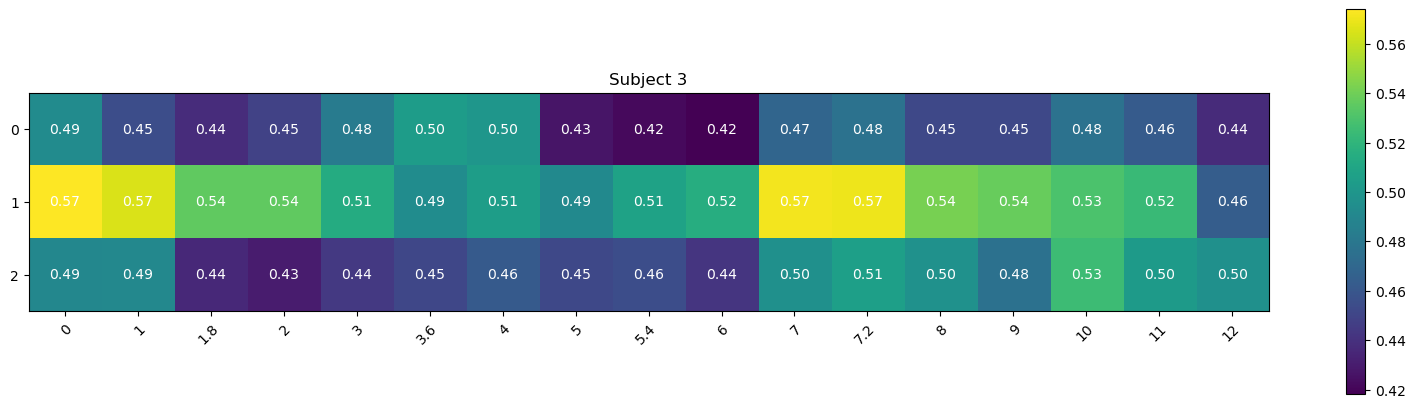

In [124]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

1

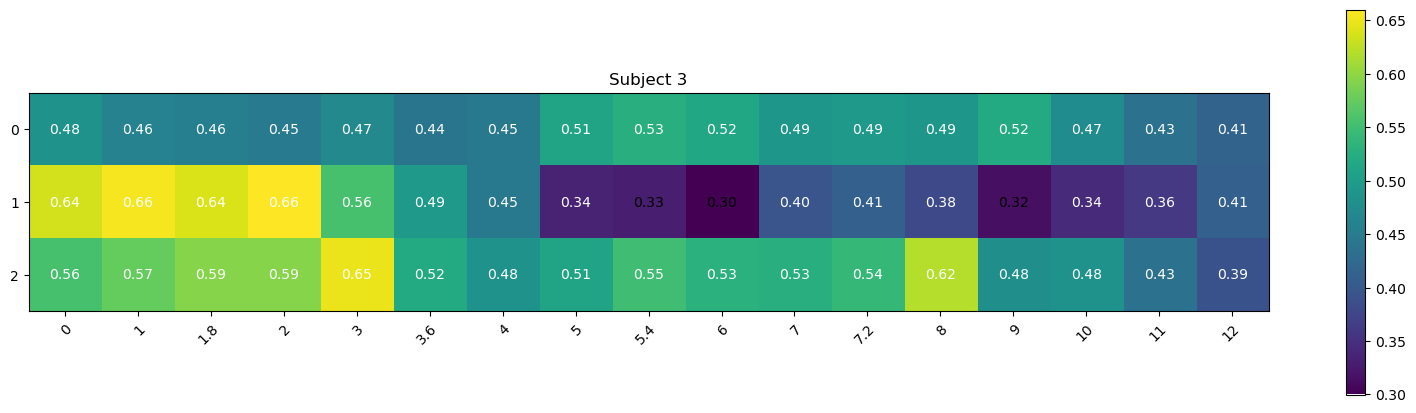

In [101]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

2

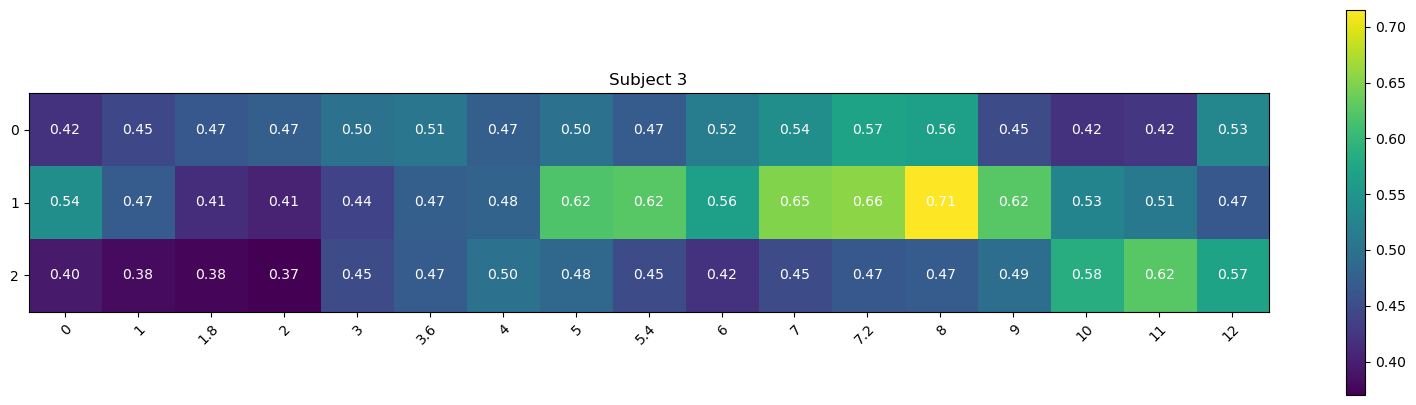

In [104]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

3

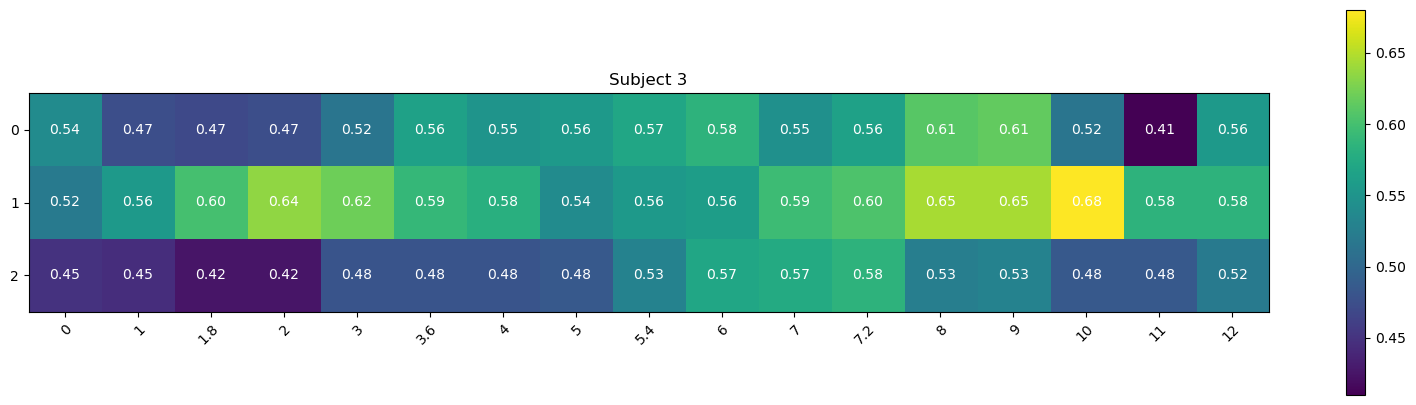

In [98]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

4

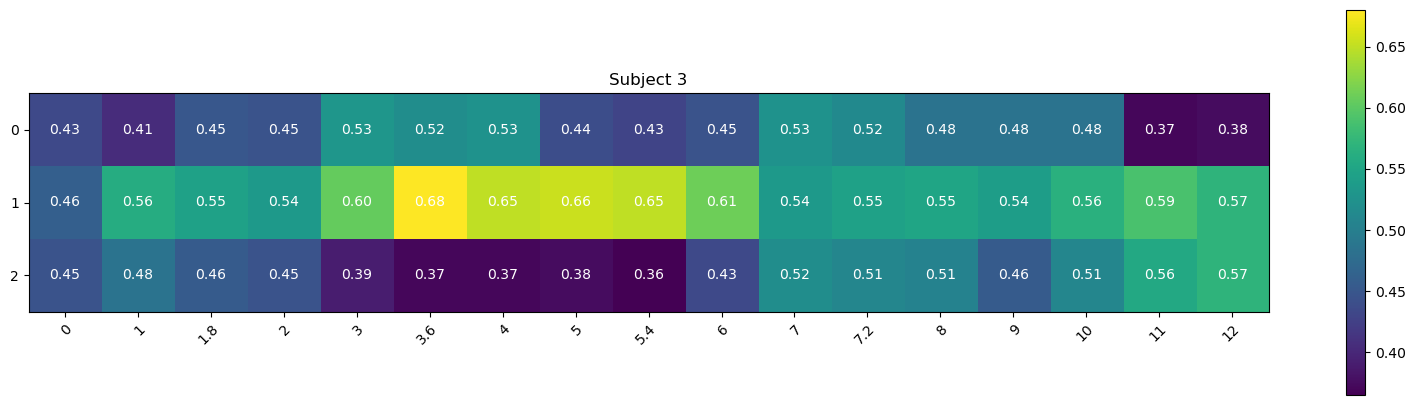

In [109]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[0]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

5

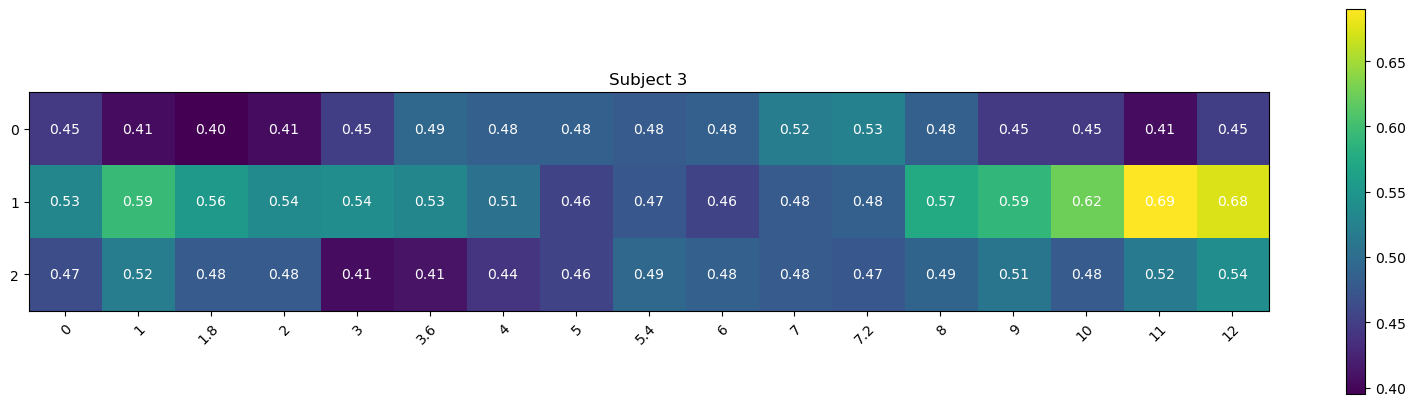

In [110]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[1]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

6

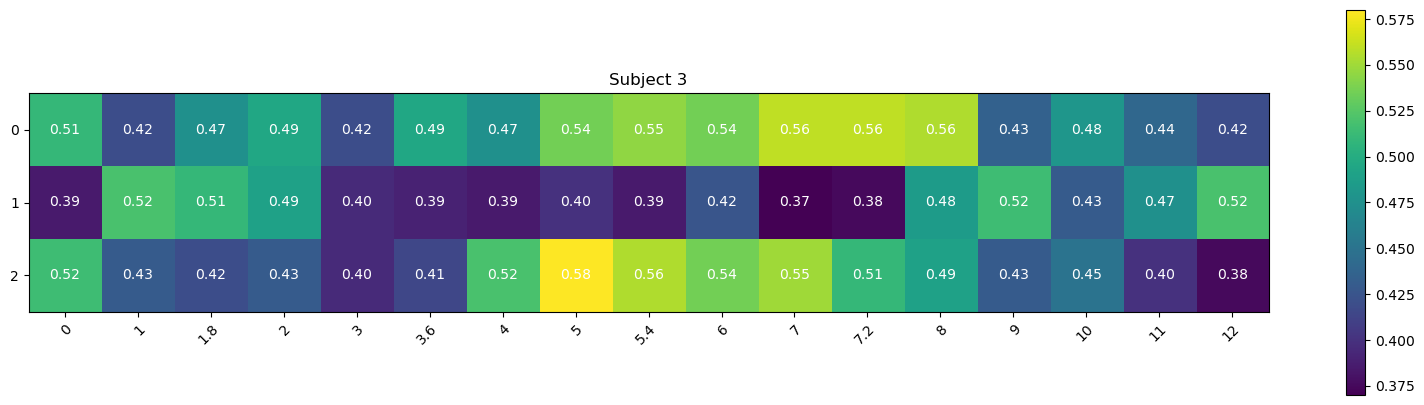

In [111]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[2]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

7

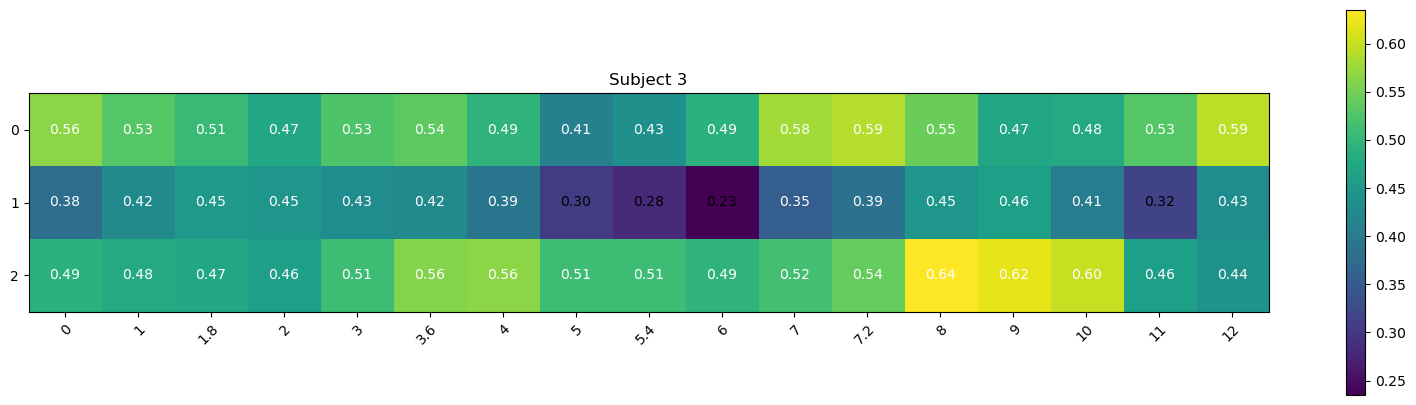

In [112]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[3]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

8

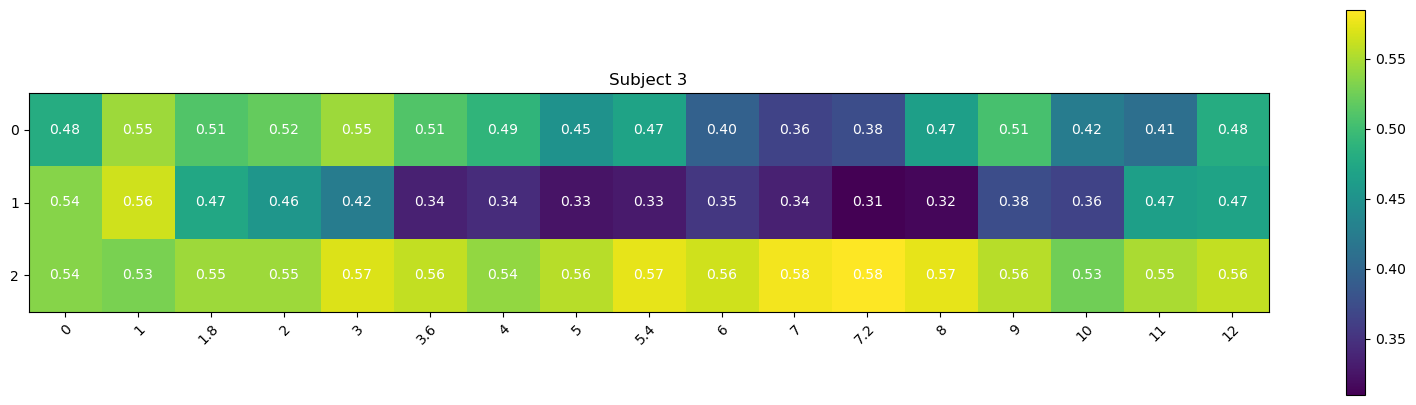

In [113]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[4]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

9

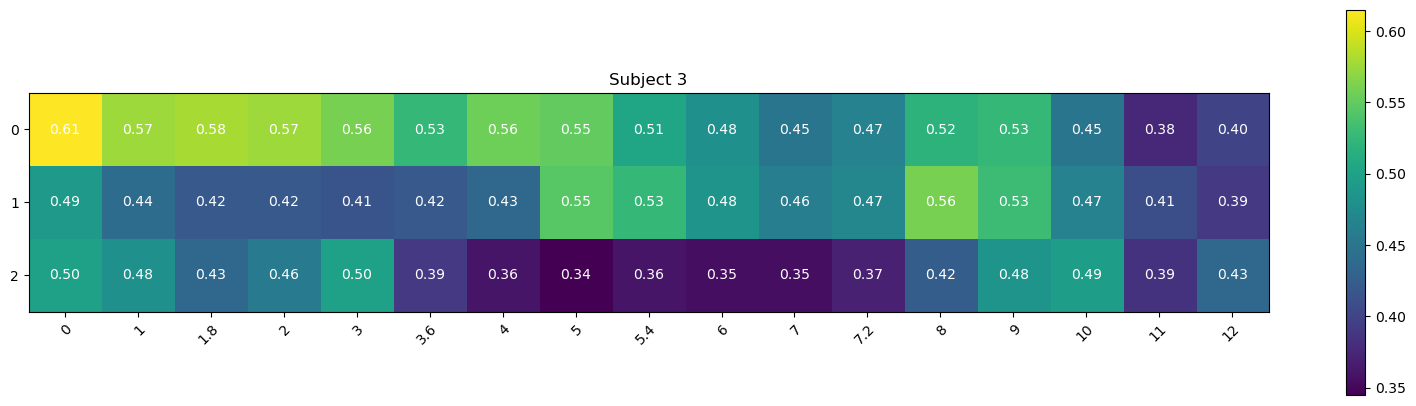

In [114]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[5]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

10

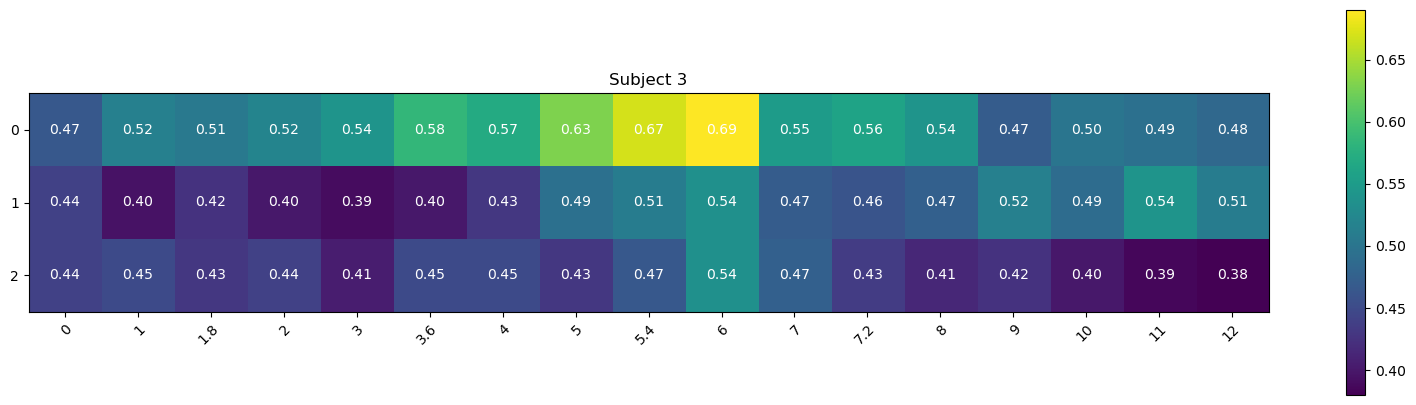

In [115]:

from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_run[6]).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

12

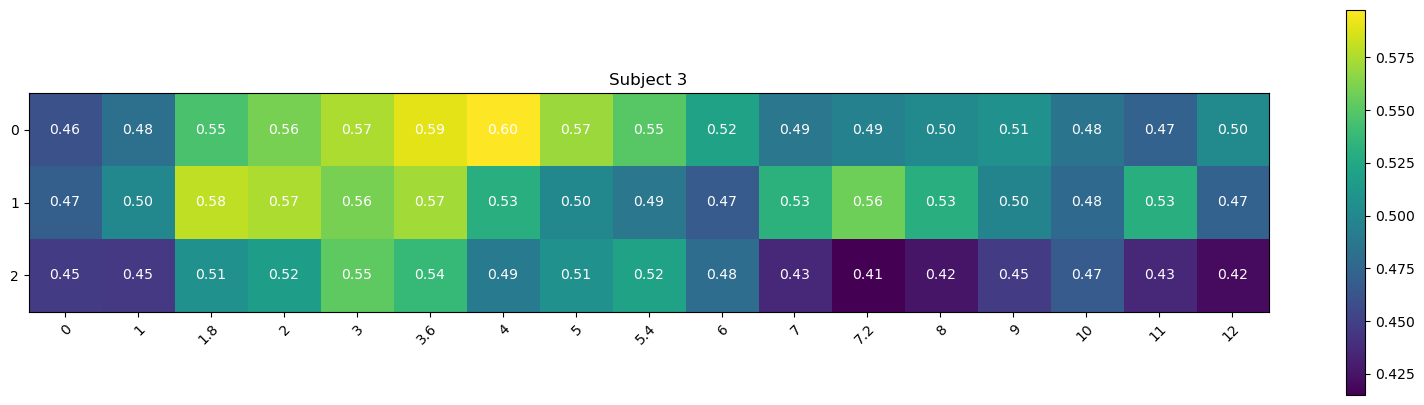

In [55]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

34

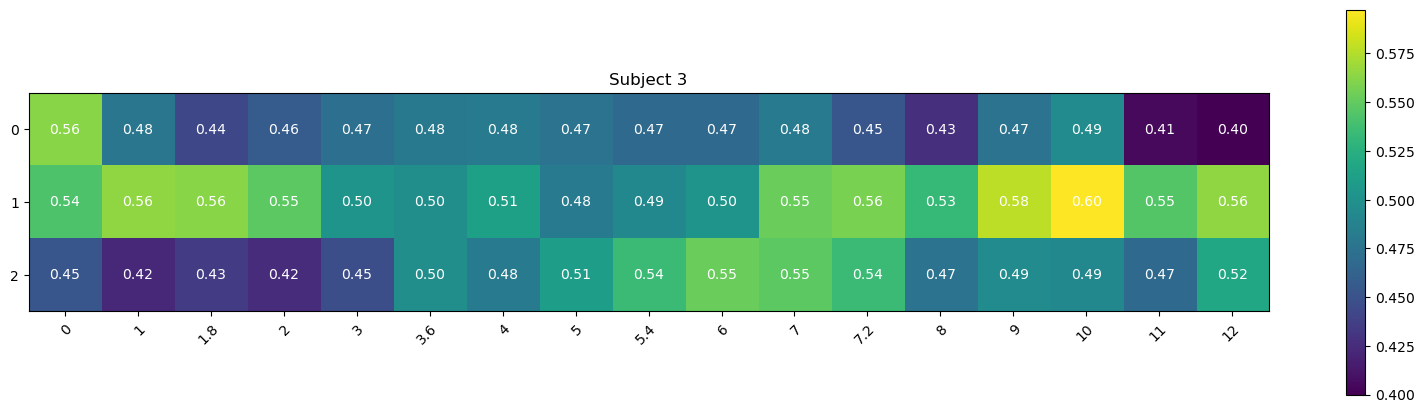

In [60]:
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

1234

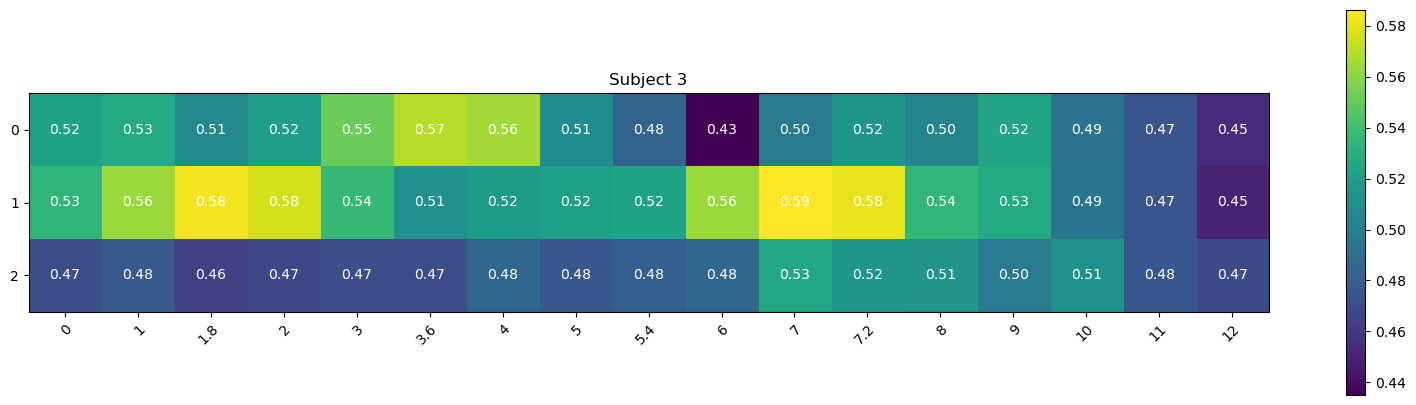

In [65]:
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

12345

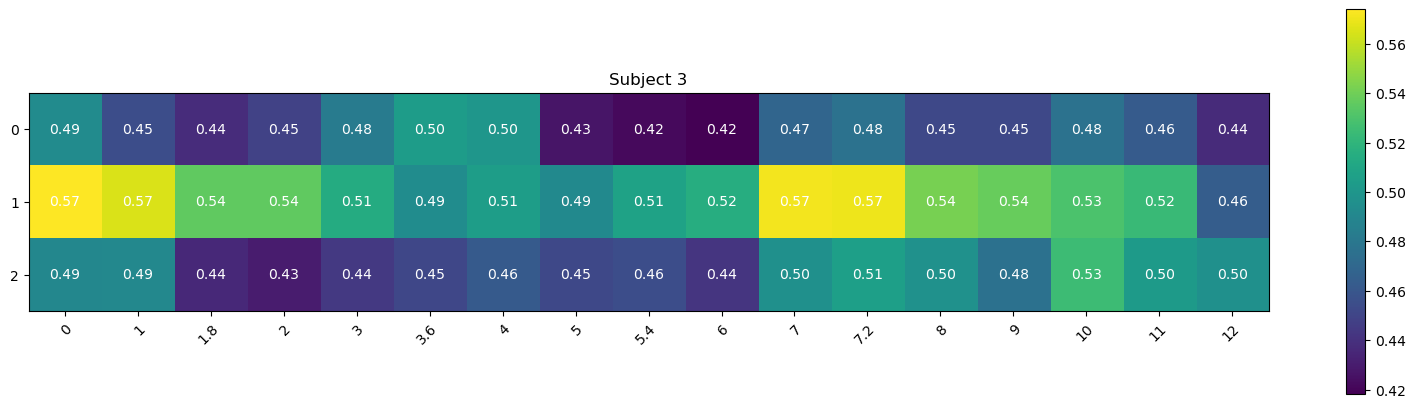

In [69]:
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

123

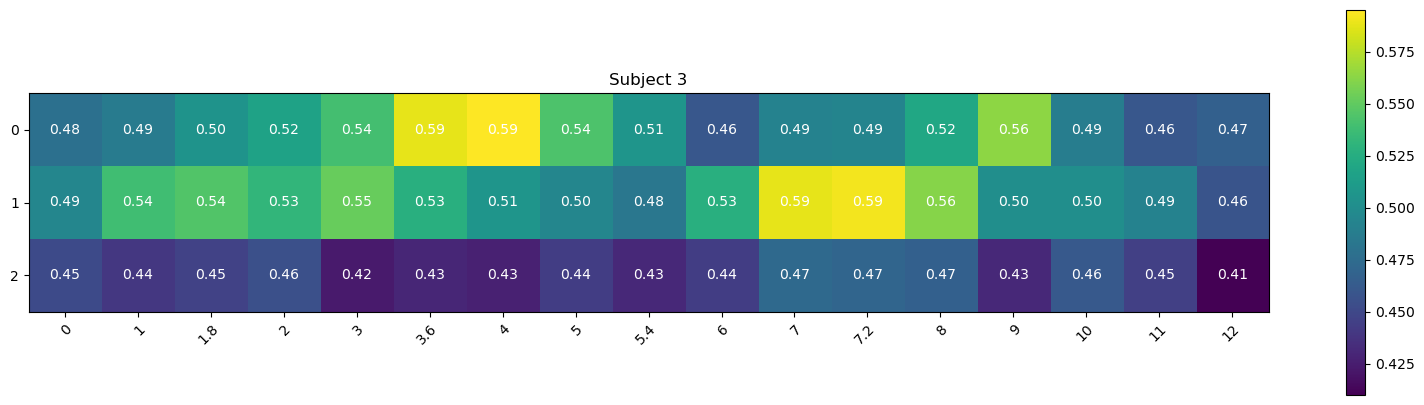

In [73]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

124

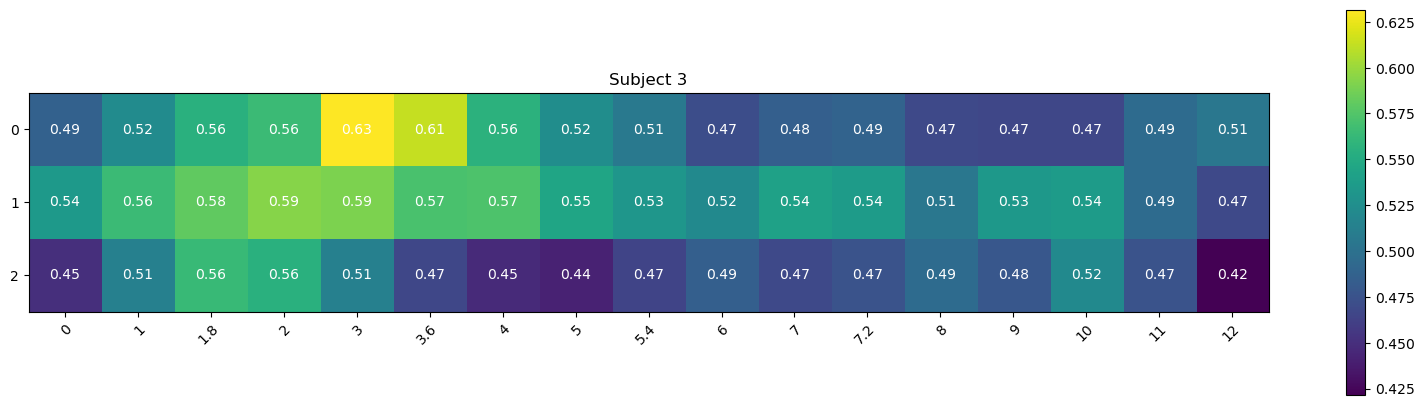

In [80]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

1,2,4,5,7,8,9,10

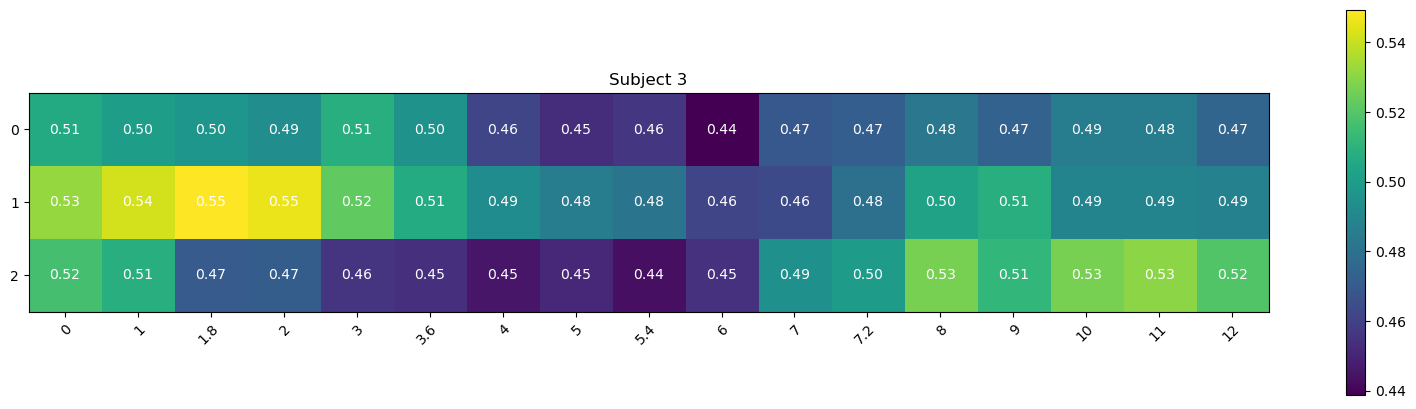

In [84]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

78910

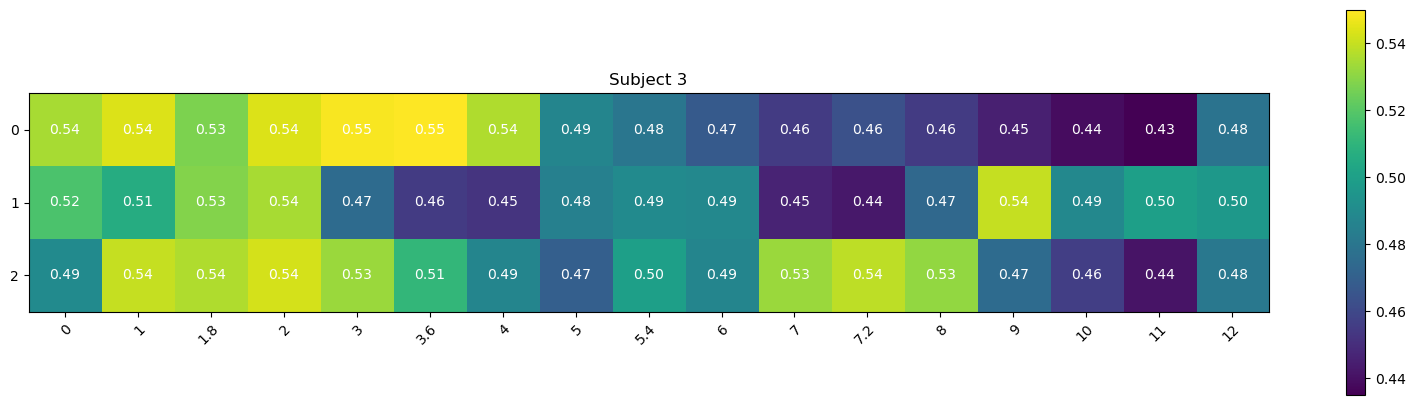

In [87]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

78

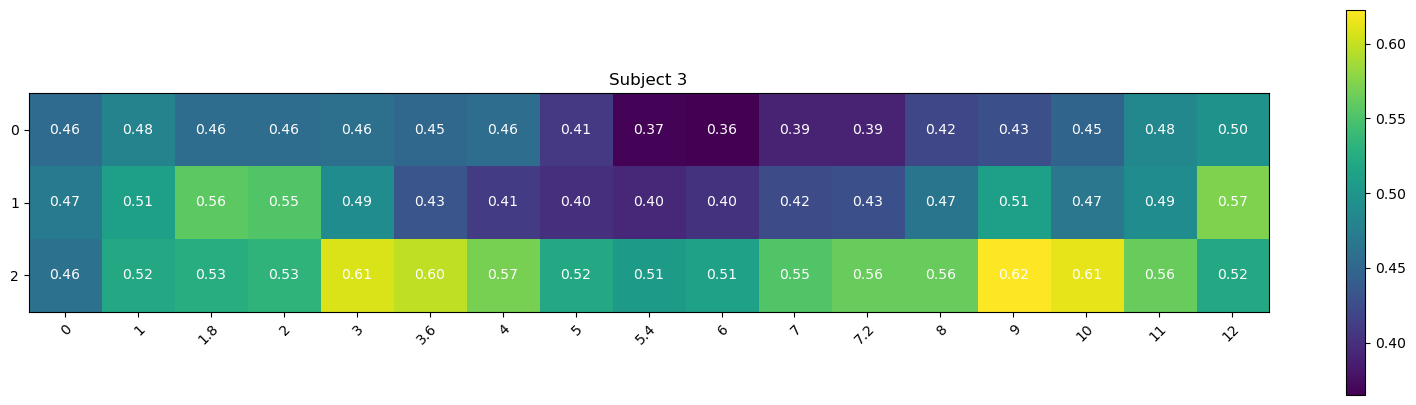

In [90]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

910

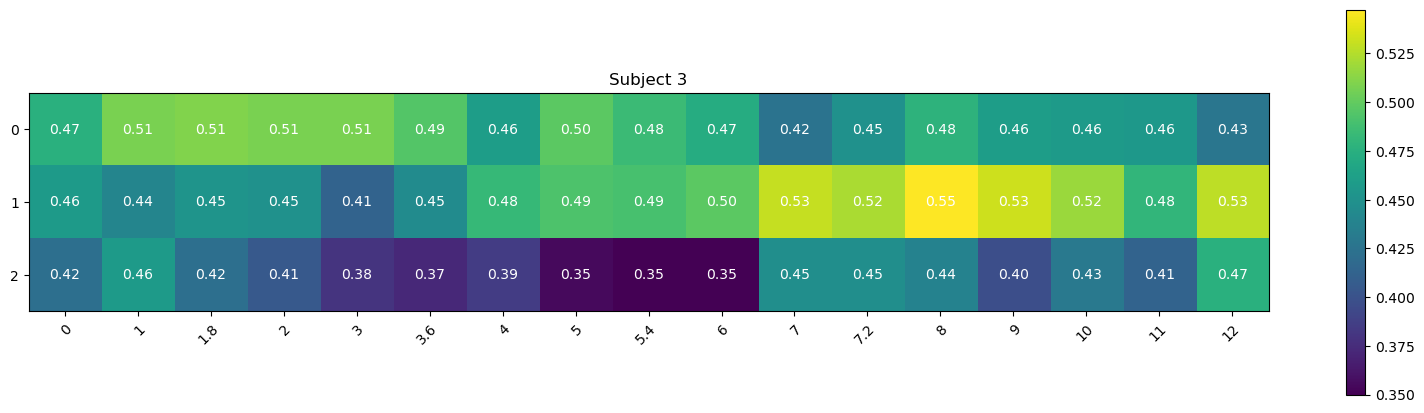

In [94]:
delay_rois_arr = np.squeeze(np.array(delay_rois),axis=1)
from mlxtend.plotting import heatmap
heatmap(np.array(delay_rois_arr).T,  column_names = delay_length, figsize=(20, 5))
plt.title("Subject 3")
plt.show()

In [44]:
np.save('./outputs/Sub1_43roi_sub2.npy', rois)

In [57]:
rois_all = []
rois_all.append(np.load('./outputs/Sub1_43roi.npy'))
rois_all.append(np.load('./outputs/Sub1_43roi_sub2.npy'))

In [60]:
rois_all = np.array(rois_all)
rois_avg = np.average(rois_all, axis=0)

(2, 43, 12)

In [63]:
rois_avg.shape

(43, 12)

In [47]:
roi_names = roi_dict.keys()

In [52]:
decode_names = []
decode_names.append('pleasant vs. neutral')
decode_names.append('pleasant vs. unpleasant')
decode_names.append('unpleasant vs. neutral')
decode_names.append('pleasant vs. neutral (natrual)')
decode_names.append('pleasant vs. unpleasant (natrual)')
decode_names.append('unpleasant vs. neutral (natrual)')
decode_names.append('pleasant vs. neutral (AI)')
decode_names.append('pleasant vs. unpleasant (AI)')
decode_names.append('unpleasant vs. neutral (AI)')
decode_names.append('AI vs. natrual (pleasant)')
decode_names.append('AI vs. natrual (neutral)')
decode_names.append('AI vs. natrual (unpleasant)')

In [48]:
deselect_roi_id = [42,41,31,30,29, 25, 26, 27]

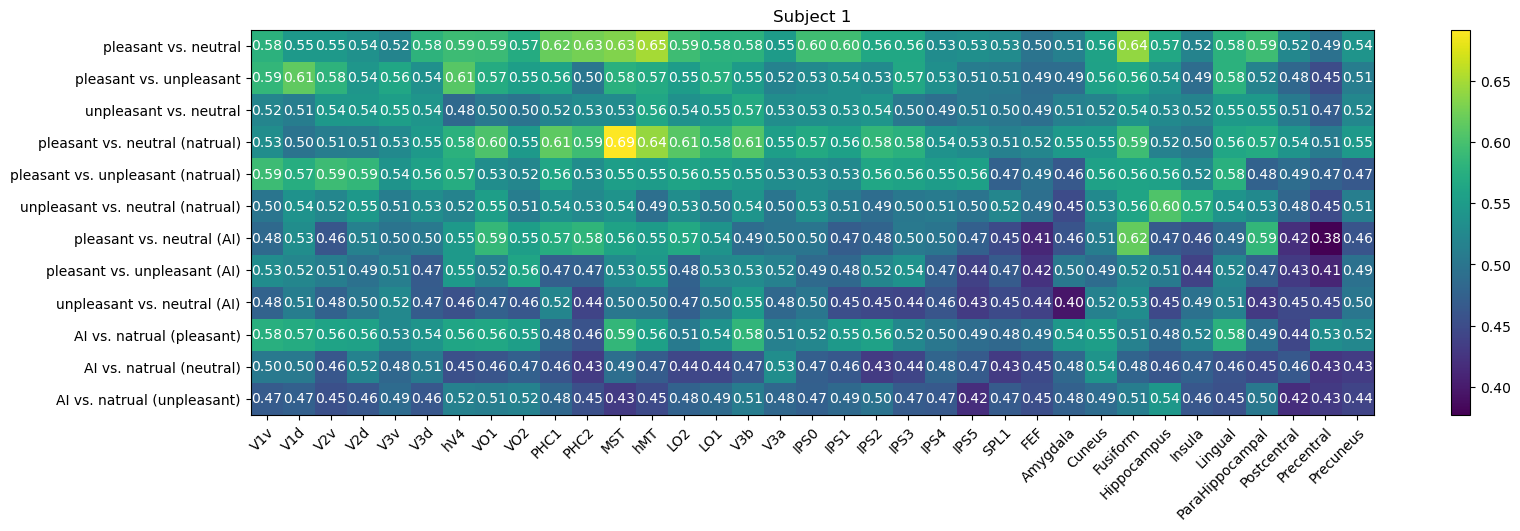

In [56]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(decode_names) if i not in deselect_roi_id], figsize=(20, 5))
plt.title("Subject 1")
plt.show()

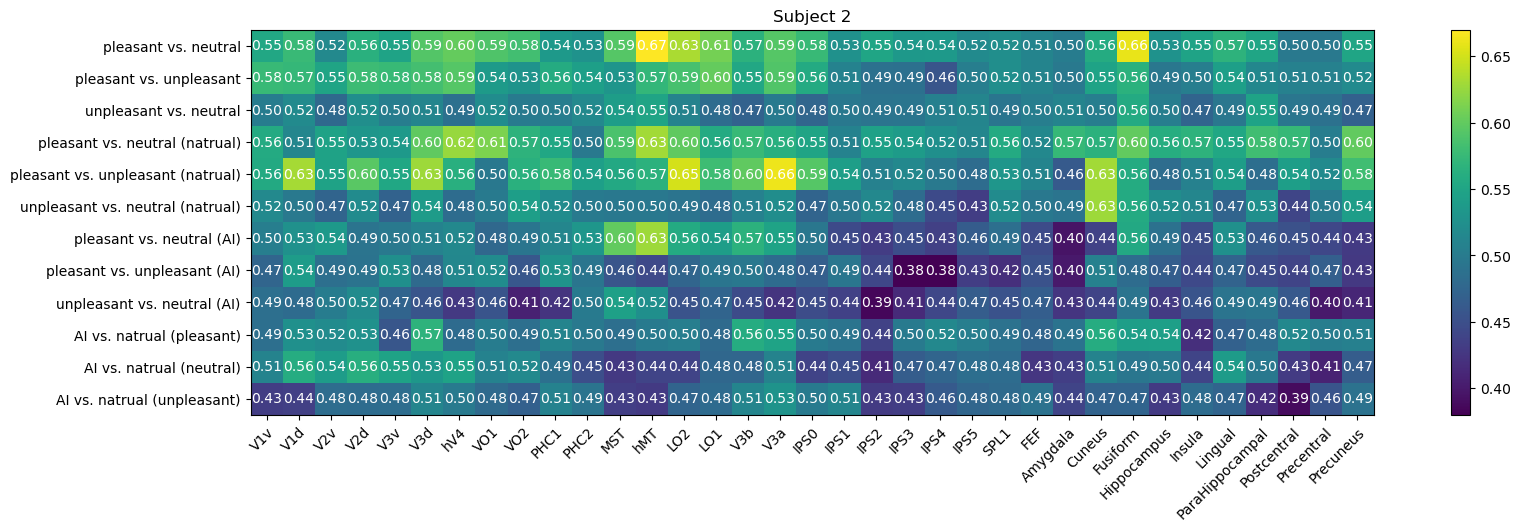

In [65]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_all[1]).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(decode_names) if i not in deselect_roi_id], figsize=(20, 5))
plt.title("Subject 2")
plt.show()

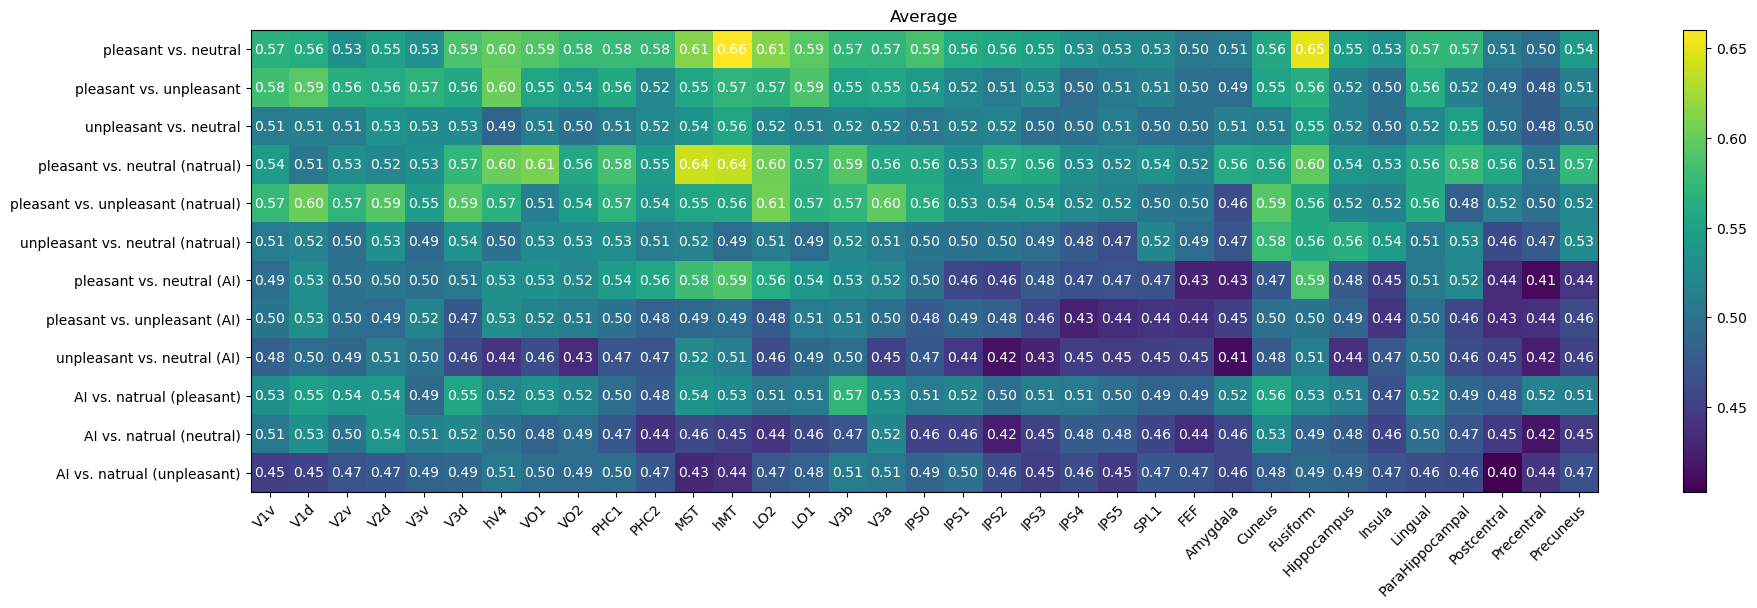

In [68]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_avg).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(decode_names) if i not in deselect_roi_id], figsize=(22, 6))
plt.title("Average")
plt.show()

In [69]:
xdecode_ids = []
xdecode_names = []

xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])

xdecode_names.append('AI (pleasant vs. neutral)')
xdecode_names.append('AI (pleasant vs. unpleasant)')
xdecode_names.append('AI (unpleasant vs. neutral)')
xdecode_names.append('natrual (pleasant vs. neutral)')
xdecode_names.append('natrual (pleasant vs. unpleasant)')
xdecode_names.append('natrual (unpleasant vs. neutral)')

In [70]:
flat_betas = beta_series.reshape((600, -1))

In [82]:
roi_bin.shape

(79, 95, 79)

In [71]:
rois_xdecode = []
# Iterate through the values of roi_dict
for roi_name, roi_bin in tqdm(roi_dict.items()):
    flat_roi = roi_bin.ravel()
    roi_betas = flat_betas[:, flat_roi == 1]

    # print(f'Now decoding {roi_name}')

    cases = []
    for i, xdecode_id in enumerate(xdecode_ids):
        data_train = roi_betas[xdecode_id, :]  # (600, number of roi voxels)
        label_train = stimuli['emotion_type'][xdecode_id].reset_index(drop=True)
        if i == 0:
            data_test = roi_betas[xdecode_ids[3], :]
            label_test = stimuli['emotion_type'][xdecode_ids[3]].reset_index(drop=True)
        elif i == 1:
            data_test = roi_betas[xdecode_ids[4], :]
            label_test = stimuli['emotion_type'][xdecode_ids[4]].reset_index(drop=True)
        elif i == 2:
            data_test = roi_betas[xdecode_ids[5], :]
            label_test = stimuli['emotion_type'][xdecode_ids[5]].reset_index(drop=True)
        elif i == 3:
            data_test = roi_betas[xdecode_ids[0], :]
            label_test = stimuli['emotion_type'][xdecode_ids[0]].reset_index(drop=True)
        elif i == 4:
            data_test = roi_betas[xdecode_ids[1], :]
            label_test = stimuli['emotion_type'][xdecode_ids[1]].reset_index(drop=True)
        else:
            data_test = roi_betas[xdecode_ids[2], :]
            label_test = stimuli['emotion_type'][xdecode_ids[2]].reset_index(drop=True)

        # Create SVC classifiers with different kernels
        linear_svc = SVC(kernel='linear')

        # Fit the model
        linear_svc.fit(data_train, label_train)

        # Evaluate the model
        linear_score = linear_svc.score(data_test, label_test)

        # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
        # print("Average Linear SVC accuracy:", avg_linear_score)
        # print("------------------")
        cases.append(linear_score)

    # print('=============================================')
    rois_xdecode.append(cases)

100%|██████████| 43/43 [01:01<00:00,  1.42s/it]


In [80]:
len(rois_xdecode)

43

In [72]:
np.save('./outputs/Sub1243ro_xdeco.npy', rois_xdecode)

In [151]:
# deselect_roi_names = ['ACCpre', 'ACCsub', 'ACCsup', 'Angular', 'Calcarine', 'Caudate', 'CingulateMid', 'CingulatePost', 'Putamen', 'ThalPuA', 'ThalPuM', 'ThalPuL', 'ThalPuI']
# deselect_roi_id = [list(roi_dict.keys()).index(item) for item in deselect_roi_names]
deselect_roi_id = [42,41,31,30,29, 25, 26, 27]

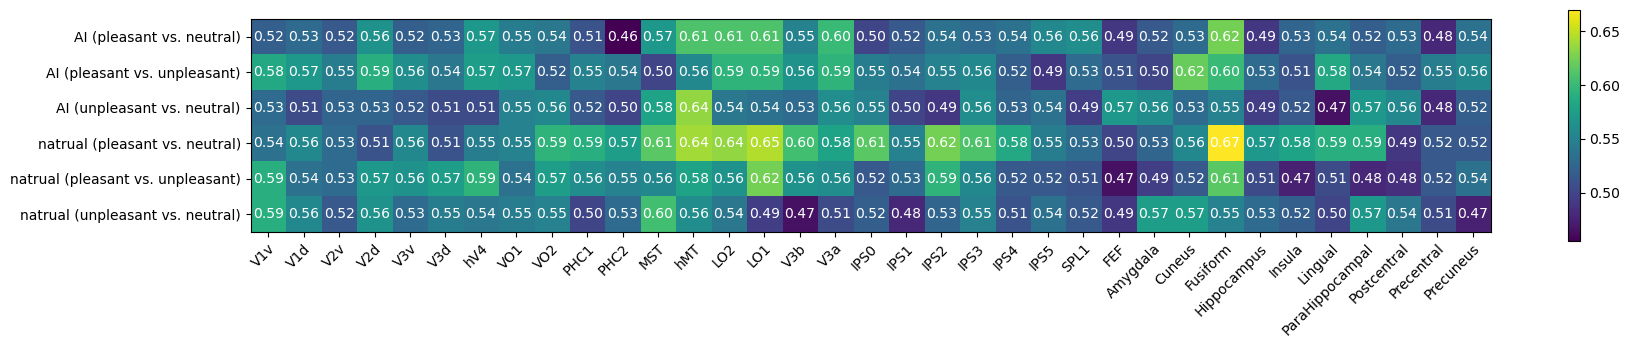

In [76]:
from mlxtend.plotting import heatmap
heatmap(np.delete(np.array(rois_xdecode).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_dict) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(20, 3))
plt.show()

In [83]:
rois_all_xdeco = []
rois_all_xdeco.append(np.load('./outputs/Sub1_43ro_xdeco.npy'))
rois_all_xdeco.append(np.load('./outputs/Sub2_43ro_xdeco.npy'))

In [84]:
rois_all_xdeco = np.array(rois_all_xdeco)
rois_avg_xdeco = np.average(rois_all_xdeco, axis=0)

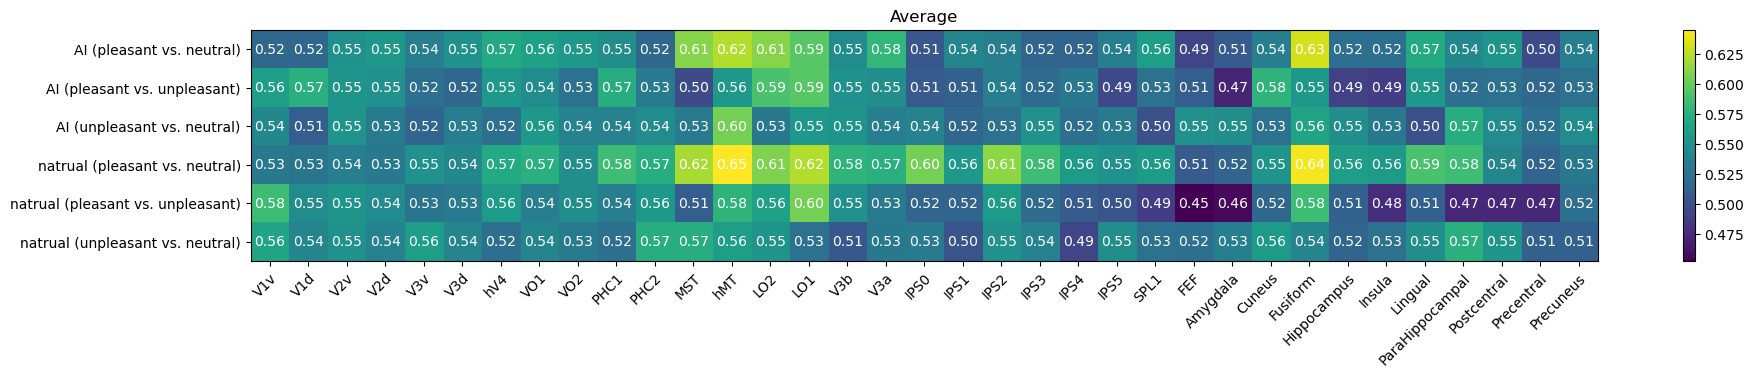

In [108]:
heatmap(np.delete(np.array(rois_avg_xdeco).T, deselect_roi_id,axis=1), column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id], row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id], figsize=(22, 3))


plt.title("Average")

plt.show()



In [106]:
rois_avg_xdeco_arr = np.delete(np.array(rois_avg_xdeco).T, deselect_roi_id,axis=1)

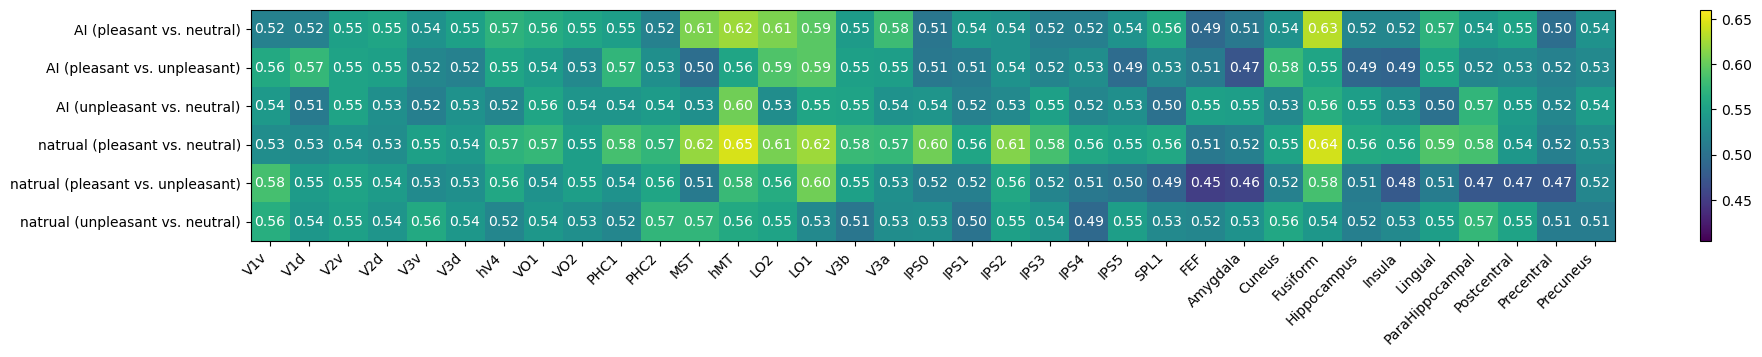

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_xdeco_arr

# Set the figure size
plt.figure(figsize=(22, 3))

# Create the heatmap
plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
row_names = [x for i, x in enumerate(xdecode_names) if i not in deselect_roi_id]
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()

Decoding differences

In [128]:
rois_avg.shape

(43, 12)

In [129]:
rois_avg_xdeco.shape

(43, 6)

In [134]:
rois_avg_nat1 = rois_avg[:,0:3]
rois_avg_nat2 = rois_avg[:,3:6]
rois_avg_nat3 = rois_avg[:,6:9]
rois_avg_xdeco_nat = rois_avg_xdeco[:,0:3]

rois_avg_diif_nat1 = rois_avg_nat1-rois_avg_xdeco_nat
rois_avg_diif_nat2 = rois_avg_nat2-rois_avg_xdeco_nat
rois_avg_diif_nat3 = rois_avg_nat3-rois_avg_xdeco_nat
rois_avg_diif_nat = np.hstack((rois_avg_diif_nat1, rois_avg_diif_nat2, rois_avg_diif_nat3))

In [140]:

rois_avg_diif_nat.shape

(43, 9)

In [145]:
len(xdecode_names)

6

In [165]:
xdecode_diff_names = ['pl-nt,ALL dc-Nat. xdc',
    'pl-up,ALL dc-Nat. xdc',
    'up-nt,ALL dc-Nat. xdc',
    'pl-nt,Natural dc-Nat. xdc',
    'pl-up,Natural dc-Nat. xdc',
    'up-nt,Natural dc-Nat. xdc',
    'pl-nt,AI dc-Nat. xdc',
    'pl-up,AI dc-Nat. xdc',
    'up-nt,AI dc-Nat. xdc',
 ]

In [150]:
len(roi_names)

43

In [153]:
heatmap_data.shape

(9, 43)

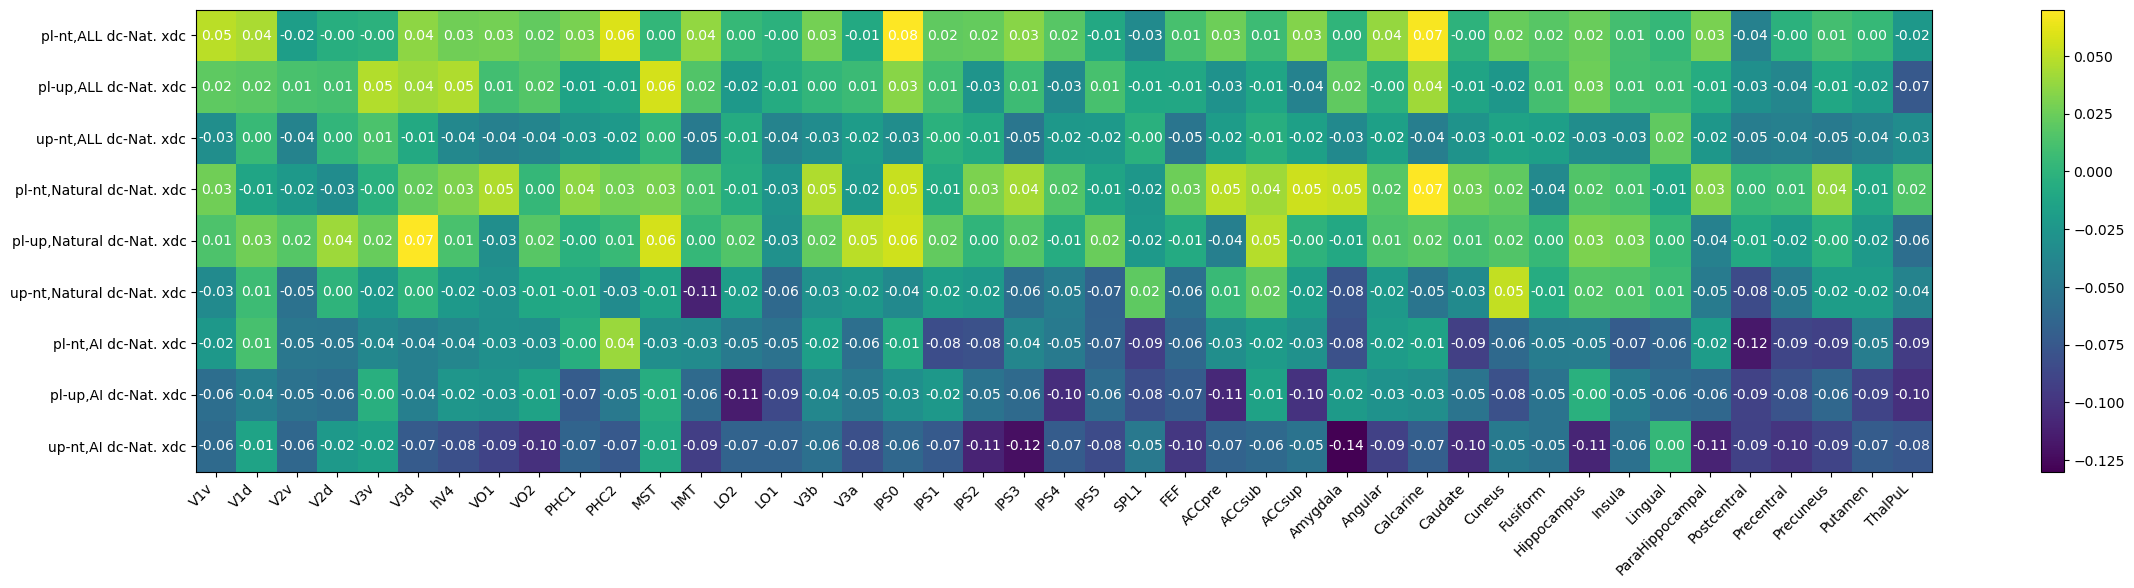

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_diif_nat.T

# Set the figure size
plt.figure(figsize=(28, 6))

# Create the heatmap
# plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)
plt.imshow(heatmap_data, cmap='viridis', aspect='auto',vmin=-0.13, vmax=0.07)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
# column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
column_names = roi_names
row_names = xdecode_diff_names
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()

- AI xdecode

In [157]:
rois_avg_xdeco.shape

(43, 6)

In [159]:
rois_avg_nat1 = rois_avg[:,0:3]
rois_avg_nat2 = rois_avg[:,3:6]
rois_avg_nat3 = rois_avg[:,6:9]
rois_avg_xdeco_ai = rois_avg_xdeco[:,3:6]

rois_avg_diif_ai1 = rois_avg_nat1-rois_avg_xdeco_ai
rois_avg_diif_ai2 = rois_avg_nat2-rois_avg_xdeco_ai
rois_avg_diif_ai3 = rois_avg_nat3-rois_avg_xdeco_ai
rois_avg_diif_ai = np.hstack((rois_avg_diif_ai1, rois_avg_diif_ai2, rois_avg_diif_ai3))

In [161]:
xdecode_diff_names = ['pl-nt,ALL dc-AI xdc',
    'pl-up,ALL dc-AI xdc',
    'up-nt,ALL dc-AI xdc',
    'pl-nt,Natural dc-AI xdc',
    'pl-up,Natural dc-AI. xdc',
    'up-nt,Natural dc-AI. xdc',
    'pl-nt,AI dc-AI xdc',
    'pl-up,AI dc-AI xdc',
    'up-nt,AI dc-AI xdc',
 ]

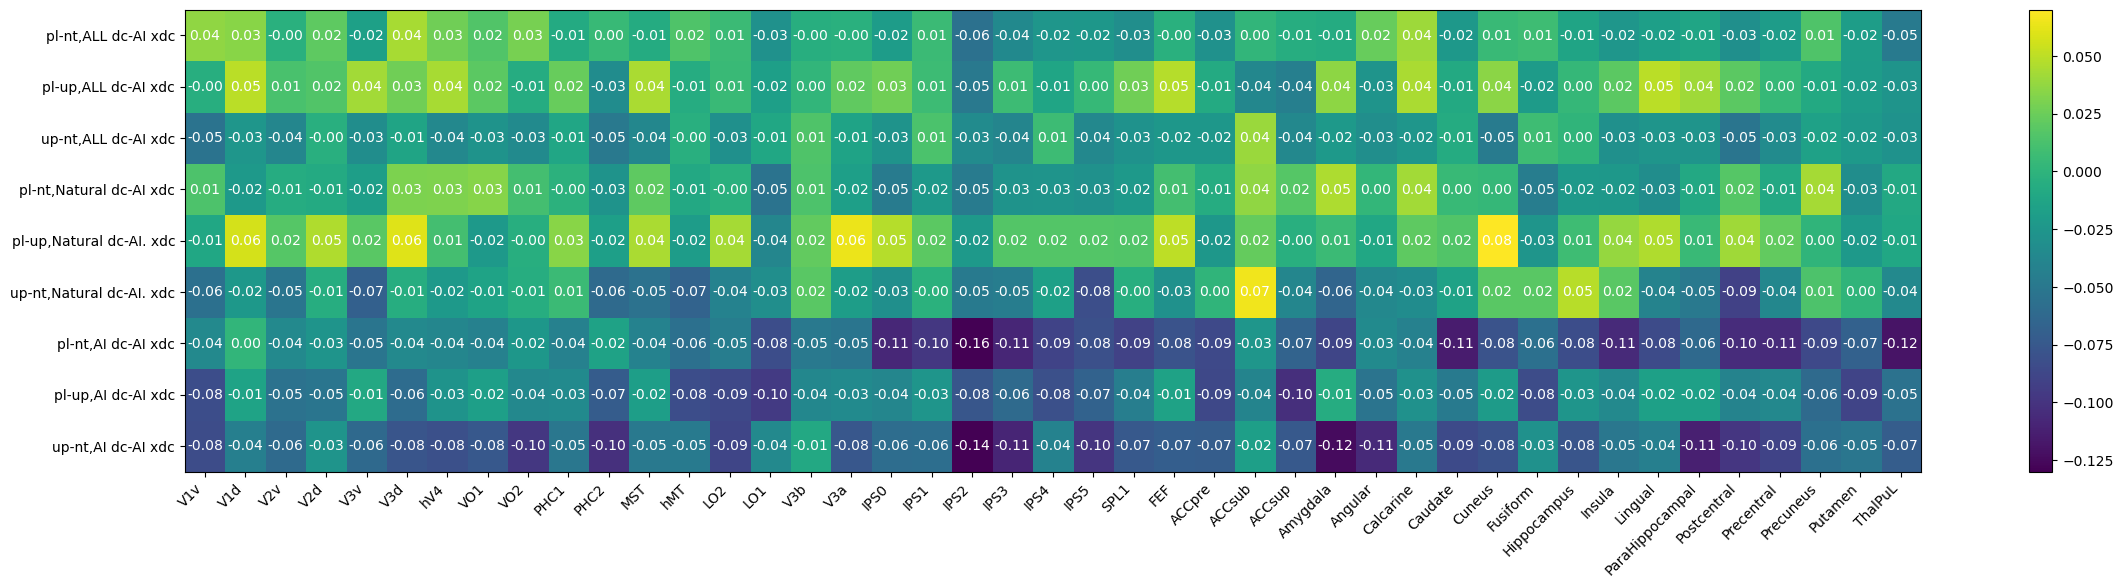

In [164]:
import matplotlib.pyplot as plt
import numpy as np

# Example heatmap data
heatmap_data = rois_avg_diif_ai.T

# Set the figure size
plt.figure(figsize=(28, 6))

# Create the heatmap
# plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0.405, vmax=0.66)
plt.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=-0.13, vmax=0.07)

# Add value annotations to the cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.annotate(f'{heatmap_data[i, j]:.2f}', 
                     (j, i), 
                     ha='center', va='center', color='white')


cbar = plt.colorbar()

# Add custom x and y ticks
# column_names = [x for i, x in enumerate(roi_names) if i not in deselect_roi_id]
column_names = roi_names
row_names = xdecode_diff_names
x_ticks = list(range((len(column_names))))
y_ticks = list(range((len(row_names))))
x_tick_labels = column_names # Replace with your desired x tick labels
y_tick_labels = row_names  # Replace with your desired y tick labels

plt.xticks(x_ticks, x_tick_labels, rotation = 45, ha='right')
plt.yticks(y_ticks, y_tick_labels)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Avr')

# Show the plot
plt.show()